Basis Encoding

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

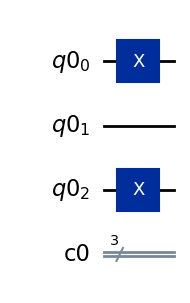

In [3]:
n = 5
s_bin = "101"
n_qbit = 3
qr = QuantumRegister(n_qbit)
cr = ClassicalRegister(n_qbit)
qc = QuantumCircuit(qr, cr)
qc.x(qr[0])
qc.x(qr[2])
qc.draw('mpl')

Enter any integer less than 64 50


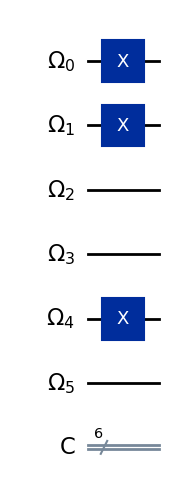

In [5]:
n = int(input("Enter any integer less than 64"))
s_bin = format(n,'06b')
n_qbit = 6
qr = QuantumRegister(n_qbit,'Ω')
cr = ClassicalRegister(n_qbit,'C')
qc = QuantumCircuit(qr, cr)
for idx,c_chr in enumerate(s_bin):
    if c_chr == '1':
        qc.x(qr[idx])
qc.draw('mpl')

Phase Encoding

In [6]:
from qiskit import QuantumRegister
sepal_length = 4.4
qb_sl = QuantumRegister(1)

In [7]:
from math import sqrt
v_zero = [1+0j,0+0j]
v_one = [0+0j,1+0j]
v_x = [1/sqrt(2)+0j, 1/sqrt(2)+0j]
v_y = [2,3]
v_z = [4.4,0]

In [8]:
qb_sl = v_zero

In [9]:
from qiskit.visualization import plot_bloch_multivector

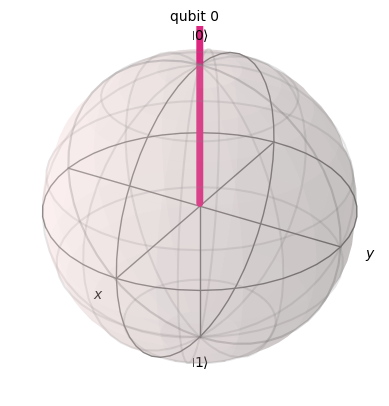

In [10]:
plot_bloch_multivector(v_z)

In [27]:
#from math import exp
from cmath import exp, cos, sin
from math import pi
from qiskit.visualization import array_to_latex, plot_state_city

x = r x exp(i x theta)
x = cos(theta) +  sin(theta)
r = mod(x)
normalize x between 0 to 2xPI

In [37]:
sepal_length = 4.4
mn = 0
mx = 2 * pi
new_sl = (sepal_length - mn) / (mx - mn)

In [38]:
v_z = [0,exp(0+1j*new_sl)]
v_z

[0, (0.76466064885073+0.6444331556485751j)]

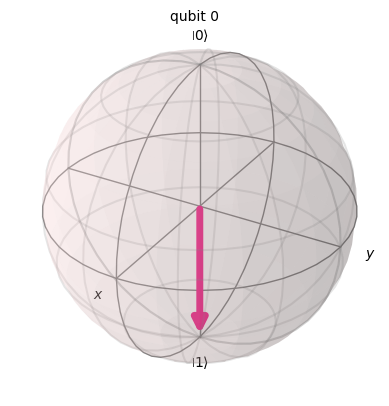

In [39]:
plot_bloch_multivector(v_z)

In [40]:
array_to_latex(v_z)

<IPython.core.display.Latex object>

In [41]:
from qiskit.visualization import array_to_latex
array_to_latex(v_z)

<IPython.core.display.Latex object>

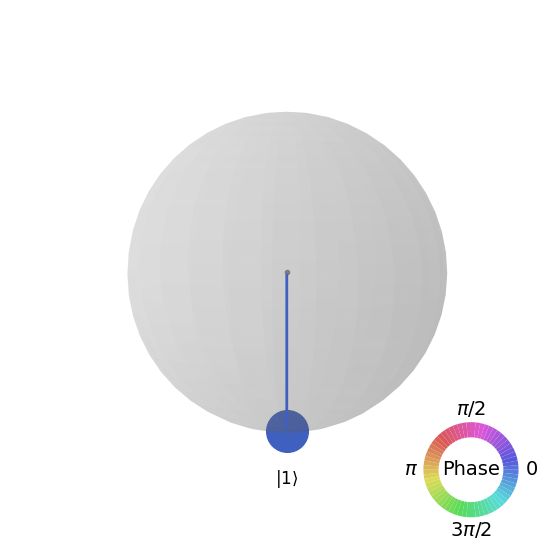

In [42]:
from qiskit.visualization import plot_state_qsphere
plot_state_qsphere(v_z)

In [43]:
v_z1 = [cos(new_sl),sin(new_sl)]

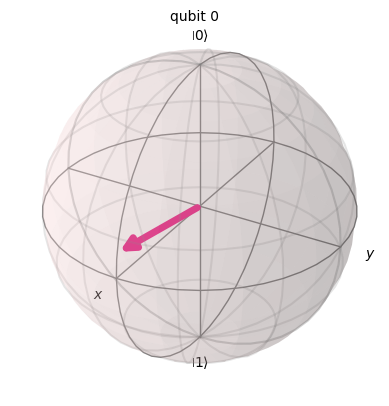

In [44]:
plot_bloch_multivector(v_z1)

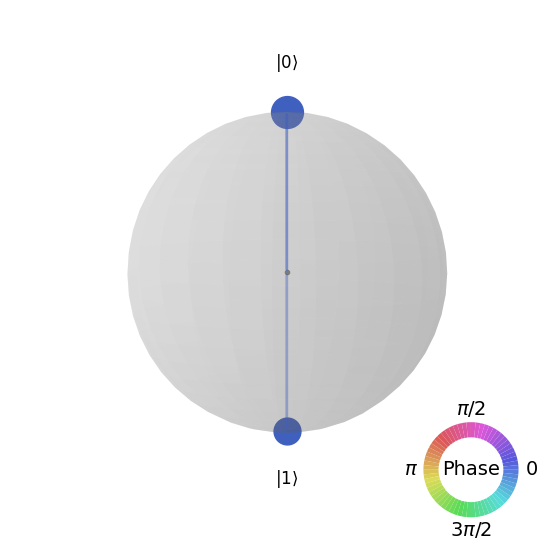

In [20]:
plot_state_qsphere(v_z1)

Amplitude Encoding
p|x>  -> probability amplitude * basis state
nth root of sum of squares of co-efficients
normalize your data between -1 to 1

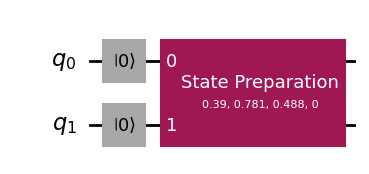

In [48]:
import math
#4^2 = 16, 8^2 = 64, 5^2 = 25, 16+64+25 = 105
#if you have 2^N elements in your vector, you need N qubits
desired_state = [
    1 / math.sqrt(105) * 4,
    1 / math.sqrt(105) * 8,
    1 / math.sqrt(105) * 5,
    1 / math.sqrt(105) * 0,
]
 
qc = QuantumCircuit(2)
qc.initialize(desired_state, [0,1], True)
 
qc.decompose(reps=1).draw(output="mpl")

In [46]:
print(desired_state)

[0.3903600291794133, 0.7807200583588266, 0.48795003647426666, 0.0]


In [ ]:
#encode using amplitude encoding 76854391
#how many qubits needed, number of digits = 2^N, find N
#in this example , 8 = 2^3, so N = 3
#what is the co-eff nth root 
#7x7 + 6x6 + 8x8 + 5x5 + 4x4 + 3x3 + 9x9 + 1 = 49 + 36 + 64 + 25 + 16 + 81 + 1 = 281

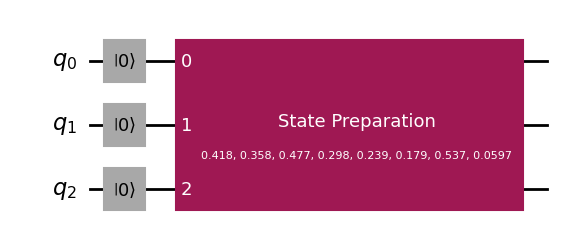

In [49]:
n_in = 76854391
n_coef = 7*7 + 6*6 + 8*8 + 5*5 + 4*4 + 3*3 + 9*9 + 1
desired_state = [
    1 / math.sqrt(n_coef) * 7,
    1 / math.sqrt(n_coef) * 6,
    1 / math.sqrt(n_coef) * 8,
    1 / math.sqrt(n_coef) * 5,
    1 / math.sqrt(n_coef) * 4,
    1 / math.sqrt(n_coef) * 3,
    1 / math.sqrt(n_coef) * 9,
    1 / math.sqrt(n_coef) * 1,
]
 
qc = QuantumCircuit(3)
qc.initialize(desired_state, [0,1,2])
 
qc.decompose(reps=1).draw(output="mpl")

Hybrid Encoding

In [61]:
import numpy as np
from qiskit.quantum_info import DensityMatrix

In [66]:
qc = QuantumCircuit(1)
dm1 = DensityMatrix(qc)
print(dm1,type(dm1))

DensityMatrix([[1.+0.j, 0.+0.j],
               [0.+0.j, 0.+0.j]],
              dims=(2,)) <class 'qiskit.quantum_info.states.densitymatrix.DensityMatrix'>


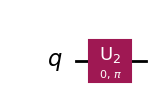

In [77]:
mat_dm = DensityMatrix([[1+0j,0+0j],[0+0j,0+0j]])
qc = QuantumCircuit(1)
qc.h(0)
#qc.initialize(mat_dm,[0])
mat_dm2 = mat_dm.evolve(qc)
qc.decompose(reps=1).draw(output="mpl")

In [75]:
print(mat_dm2)

DensityMatrix([[0.5+0.j, 0.5+0.j],
               [0.5+0.j, 0.5+0.j]],
              dims=(2,))
